# Entrenamiento de Memoria Ortogonal (2 Fases)

**Hipotesis:** La memoria de DeMemte es una conexion residual:
$$\text{enhanced} = \text{features} + \alpha \cdot \sigma \cdot \hat{x}$$

Si el clasificador es un experto en datos limpios y lo **congelamos**, la memoria solo
puede mejorar la clasificacion traduciendo los features ruidosos al lenguaje que el
clasificador ya entiende. No deberia haber degradacion en Clean.

## Protocolo
| Modelo | Fase 1 (15 ep, clean) | Fase 2 (15 ep, noisy) | Componentes entrenados Fase 2 |
|---|---|---|---|
| **ResNet Baseline** | -- | Clasificador desde cero con 50% ruido | fc |
| **DeMemte Spatial** | Todo (clean) -> Experto | Solo memoria (noisy), clasificador **congelado** | conv_vae, signal_gamma, memory_scale |

**Loss Fase 2 DeMemte:** CrossEntropy(logits, labels) + 0.1*(Recon + KLD) con clasificador congelado.

**Comparacion justa:** ResNet entrena su clasificador desde cero con datos mixtos (50% noisy) durante
15 epochs -- las mismas condiciones de exposicion al ruido pero sin mecanismo de memoria.

In [1]:
import os
import copy
import random
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nnls -ld /shared/Code
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Componentes base

In [2]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True, hard_threshold=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x):
        if x.ndim != 2 or x.shape[1] != self.in_features:
            raise ValueError(f'x debe ser (B, {self.in_features})')
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self):
        return torch.sigmoid(self.logits / self.temperature).mean()


class ConvVAE(nn.Module):
    def __init__(self, channels=512, latent_dim=128, spatial=7):
        super().__init__()
        self.channels = channels
        self.spatial = spatial
        self.enc = nn.Sequential(
            nn.Conv2d(channels, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        flat_dim = 128 * spatial * spatial
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, flat_dim)
        self.dec = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, channels, 3, padding=1),
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, self.spatial, self.spatial)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class DeMemte_Spatial(nn.Module):
    def __init__(self, spatial_backbone, conv_vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = spatial_backbone
        self.conv_vae = conv_vae
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            spatial_feats = self.backbone(x)
        spatial_rec, mu, logvar = self.conv_vae(spatial_feats)
        recon_diff = ((spatial_feats - spatial_rec) ** 2).mean(dim=1, keepdim=True)
        gamma = F.softplus(self.signal_gamma)
        signal = torch.exp(-recon_diff * gamma)
        enhanced_spatial = spatial_feats + self.memory_scale * signal * spatial_rec
        features = self.feat_norm(self.pool(spatial_feats).flatten(1))
        enhanced = self.feat_norm(self.pool(enhanced_spatial).flatten(1))
        logits = self.classifier(enhanced)
        x_rec = self.pool(spatial_rec).flatten(1)
        return logits, x_rec, mu, logvar, features

    def train(self, mode=True):
        super().train(mode)
        self.backbone.eval()
        return self


def make_spatial_backbone():
    base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    backbone = nn.Sequential(*list(base.children())[:-2])
    for p in backbone.parameters():
        p.requires_grad = False
    backbone.eval()
    return backbone


EMBEDDING_DIM = 512
NUM_CLASSES = 102
LATENT_DIM = 128
print('Componentes definidos.')

Componentes definidos.


## Datos

In [3]:
BATCH_SIZE = 64
NOISE_STD = 0.5
EPOCHS_P1 = 15
EPOCHS_P2 = 15
DATA_DIR = '../data'

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

trainset = torchvision.datasets.Flowers102(root=DATA_DIR, split='train', download=True, transform=transform_train)
testset  = torchvision.datasets.Flowers102(root=DATA_DIR, split='test',  download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {len(trainset)} | Test: {len(testset)}')


def add_noise(x, std=NOISE_STD):
    return x + torch.randn_like(x) * std

Train: 1020 | Test: 6149


## Utilidades de evaluacion

In [4]:
@torch.no_grad()
def evaluate(model, loader, noise_std=0.0, is_dememte=True):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if noise_std > 0:
            x = add_noise(x, std=noise_std)
        if is_dememte:
            logits = model(x)[0]
        else:
            logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / total

print('Evaluacion definida.')

Evaluacion definida.


---
## 1. ResNet Baseline (entrenado desde cero con 50% ruido)

Backbone congelado (ImageNet) + clasificador lineal entrenado durante 15 epochs
con inyeccion de ruido gaussiano (std=0.5) al 50% de los batches.

In [5]:
def get_resnet_baseline(num_classes=NUM_CLASSES):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet = get_resnet_baseline()
opt_resnet = optim.Adam(resnet.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_resnet = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== ResNet Baseline (50% Noisy Training) ===')
for epoch in range(EPOCHS_P1):
    resnet.train()
    correct, total = 0, 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        if random.random() < 0.5:
            x = add_noise(x)
        opt_resnet.zero_grad()
        logits = resnet(x)
        loss = criterion(logits, y)
        loss.backward()
        opt_resnet.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(resnet, testloader, noise_std=0.0, is_dememte=False)
    noisy_acc = evaluate(resnet, testloader, noise_std=NOISE_STD, is_dememte=False)
    history_resnet['train_acc'].append(train_acc)
    history_resnet['clean_acc'].append(clean_acc)
    history_resnet['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

print(f'\nResNet final -> Clean: {history_resnet["clean_acc"][-1]:.2f}% | Noisy: {history_resnet["noisy_acc"][-1]:.2f}%')

=== ResNet Baseline (50% Noisy Training) ===
  Epoch 1/15 | Train: 2.9% | Clean: 4.6% | Noisy: 5.6%
  Epoch 2/15 | Train: 20.5% | Clean: 21.7% | Noisy: 16.5%
  Epoch 3/15 | Train: 48.6% | Clean: 16.0% | Noisy: 28.1%
  Epoch 4/15 | Train: 70.3% | Clean: 39.0% | Noisy: 31.6%
  Epoch 5/15 | Train: 71.0% | Clean: 21.1% | Noisy: 41.4%
  Epoch 6/15 | Train: 79.7% | Clean: 22.4% | Noisy: 46.0%
  Epoch 7/15 | Train: 85.8% | Clean: 38.0% | Noisy: 43.8%
  Epoch 8/15 | Train: 88.6% | Clean: 45.2% | Noisy: 46.1%
  Epoch 9/15 | Train: 90.6% | Clean: 39.7% | Noisy: 44.6%
  Epoch 10/15 | Train: 89.9% | Clean: 25.3% | Noisy: 53.2%
  Epoch 11/15 | Train: 93.1% | Clean: 39.1% | Noisy: 51.8%
  Epoch 12/15 | Train: 91.3% | Clean: 16.8% | Noisy: 56.9%
  Epoch 13/15 | Train: 94.2% | Clean: 26.1% | Noisy: 53.3%
  Epoch 14/15 | Train: 95.5% | Clean: 58.7% | Noisy: 50.1%
  Epoch 15/15 | Train: 96.0% | Clean: 52.2% | Noisy: 49.0%

ResNet final -> Clean: 52.22% | Noisy: 49.00%


---
## 2. DeMemte Spatial -- Fase 1: Experto Clean

Entrenamos **todos** los componentes (ConvVAE + clasificador + gating) exclusivamente
con imagenes limpias durante 15 epochs. El objetivo es obtener el maximo Clean Accuracy
posible -- este sera nuestro techo a no perder.

In [6]:
def compute_loss(logits, labels, x_rec, features, mu, logvar, model,
                 sparsity_weight=0.002, vae_weight=0.1):
    task = F.cross_entropy(logits, labels)
    recon = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    s_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task + vae_weight * (recon + kld) + sparsity_weight * s_loss


model = DeMemte_Spatial(
    make_spatial_backbone(),
    ConvVAE(channels=512, latent_dim=LATENT_DIM, spatial=7),
    EMBEDDING_DIM, NUM_CLASSES
).to(device)

opt_p1 = optim.Adam([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-2},
    {'params': [model.signal_gamma, model.memory_scale, *model.feat_norm.parameters()], 'lr': 1e-2},
])

history_p1 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== FASE 1: Entrenamiento Clean (Experto) ===')
for epoch in range(EPOCHS_P1):
    model.train()
    correct, total = 0, 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        opt_p1.zero_grad()
        logits, x_rec, mu, logvar, features = model(x)
        loss = compute_loss(logits, y, x_rec, features, mu, logvar, model)
        loss.backward()
        opt_p1.step()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)
    history_p1['train_acc'].append(train_acc)
    history_p1['clean_acc'].append(clean_acc)
    history_p1['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P1} | Train: {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

phase1_clean = history_p1['clean_acc'][-1]
phase1_noisy = history_p1['noisy_acc'][-1]
print(f'\n>>> Fase 1 completada -> Clean: {phase1_clean:.2f}% | Noisy: {phase1_noisy:.2f}%')
print(f'>>> Este {phase1_clean:.2f}% es nuestro TECHO. La Fase 2 no debe perderlo.')

=== FASE 1: Entrenamiento Clean (Experto) ===
  Epoch 1/15 | Train: 29.1% | Clean: 59.9% | Noisy: 25.1%
  Epoch 2/15 | Train: 81.0% | Clean: 74.4% | Noisy: 32.6%
  Epoch 3/15 | Train: 93.5% | Clean: 77.9% | Noisy: 35.8%
  Epoch 4/15 | Train: 97.7% | Clean: 79.1% | Noisy: 37.0%
  Epoch 5/15 | Train: 98.6% | Clean: 79.4% | Noisy: 36.5%
  Epoch 6/15 | Train: 99.2% | Clean: 79.9% | Noisy: 37.1%
  Epoch 7/15 | Train: 99.1% | Clean: 79.8% | Noisy: 37.5%
  Epoch 8/15 | Train: 98.9% | Clean: 79.9% | Noisy: 36.6%
  Epoch 9/15 | Train: 99.1% | Clean: 79.9% | Noisy: 37.2%
  Epoch 10/15 | Train: 99.2% | Clean: 80.4% | Noisy: 37.1%
  Epoch 11/15 | Train: 99.1% | Clean: 80.2% | Noisy: 37.0%
  Epoch 12/15 | Train: 99.4% | Clean: 80.6% | Noisy: 36.4%
  Epoch 13/15 | Train: 99.2% | Clean: 80.3% | Noisy: 36.2%
  Epoch 14/15 | Train: 99.3% | Clean: 80.4% | Noisy: 36.1%
  Epoch 15/15 | Train: 99.4% | Clean: 80.4% | Noisy: 36.6%

>>> Fase 1 completada -> Clean: 80.42% | Noisy: 36.56%
>>> Este 80.42% es nue

In [7]:
# Guardar snapshot del clasificador para verificacion posterior
classifier_snapshot = {k: v.clone() for k, v in model.classifier.state_dict().items()}
feat_norm_snapshot  = {k: v.clone() for k, v in model.feat_norm.state_dict().items()}
print(f'Snapshot del clasificador guardado ({len(classifier_snapshot)} tensores).')
print(f'Snapshot de feat_norm guardado ({len(feat_norm_snapshot)} tensores).')

Snapshot del clasificador guardado (3 tensores).
Snapshot de feat_norm guardado (2 tensores).


---
## 3. DeMemte Spatial -- Fase 2: Memoria Ortogonal

**Congelamos** el clasificador y feat_norm. Solo entrenamos:
- conv_vae (encoder + decoder convolucional)
- signal_gamma (sensibilidad de la compuerta)
- memory_scale (magnitud del vector de memoria)

Entrenamos con **100% imagenes ruidosas** (std=0.5). La Loss es Cross-Entropy + VAE.
El clasificador congelado obliga al VAE a producir un vector enhanced que el
clasificador experto pueda interpretar correctamente.

In [8]:
# === CONGELAR clasificador y feat_norm ===
for p in model.classifier.parameters():
    p.requires_grad = False
for p in model.feat_norm.parameters():
    p.requires_grad = False

trainable = {n: p.numel() for n, p in model.named_parameters() if p.requires_grad}
frozen    = {n: p.numel() for n, p in model.named_parameters() if not p.requires_grad}

print('--- Parametros ENTRENABLES (Fase 2) ---')
for n, count in trainable.items():
    print(f'  {n}: {count:,}')
print(f'  TOTAL entrenable: {sum(trainable.values()):,}')
print(f'\n--- Parametros CONGELADOS ---')
print(f'  TOTAL congelado: {sum(frozen.values()):,}  ({len(frozen)} tensores)')

--- Parametros ENTRENABLES (Fase 2) ---
  signal_gamma: 1
  memory_scale: 1
  conv_vae.enc.0.weight: 1,179,648
  conv_vae.enc.0.bias: 256
  conv_vae.enc.1.weight: 256
  conv_vae.enc.1.bias: 256
  conv_vae.enc.3.weight: 294,912
  conv_vae.enc.3.bias: 128
  conv_vae.enc.4.weight: 128
  conv_vae.enc.4.bias: 128
  conv_vae.fc_mu.weight: 802,816
  conv_vae.fc_mu.bias: 128
  conv_vae.fc_logvar.weight: 802,816
  conv_vae.fc_logvar.bias: 128
  conv_vae.fc_dec.weight: 802,816
  conv_vae.fc_dec.bias: 6,272
  conv_vae.dec.0.weight: 294,912
  conv_vae.dec.0.bias: 256
  conv_vae.dec.1.weight: 256
  conv_vae.dec.1.bias: 256
  conv_vae.dec.3.weight: 1,179,648
  conv_vae.dec.3.bias: 512
  TOTAL entrenable: 5,366,530

--- Parametros CONGELADOS ---
  TOTAL congelado: 11,282,086  (65 tensores)


In [9]:
opt_p2 = optim.Adam([
    {'params': model.conv_vae.parameters(), 'lr': 3e-5},
    {'params': [model.signal_gamma, model.memory_scale], 'lr': 1e-3},
])

history_p2 = {'train_acc': [], 'clean_acc': [], 'noisy_acc': []}

print('=== FASE 2: Entrenamiento de Memoria Ortogonal (clasificador CONGELADO) ===')
for epoch in range(EPOCHS_P2):
    model.train()
    correct, total = 0, 0

    temp = max(0.3, 1.0 - 0.05 * epoch)
    for m in model.conv_vae.modules():
        if isinstance(m, LearnedSparseLinear):
            m.temperature = temp

    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        x_noisy = add_noise(x)

        opt_p2.zero_grad()
        logits, x_rec, mu, logvar, features = model(x_noisy)
        loss = compute_loss(logits, y, x_rec, features, mu, logvar, model)
        loss.backward()
        opt_p2.step()

        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    clean_acc = evaluate(model, testloader, noise_std=0.0)
    noisy_acc = evaluate(model, testloader, noise_std=NOISE_STD)
    history_p2['train_acc'].append(train_acc)
    history_p2['clean_acc'].append(clean_acc)
    history_p2['noisy_acc'].append(noisy_acc)
    print(f'  Epoch {epoch+1}/{EPOCHS_P2} | Train(noisy): {train_acc:.1f}% | Clean: {clean_acc:.1f}% | Noisy: {noisy_acc:.1f}%')

phase2_clean = history_p2['clean_acc'][-1]
phase2_noisy = history_p2['noisy_acc'][-1]
print(f'\n>>> Fase 2 completada -> Clean: {phase2_clean:.2f}% | Noisy: {phase2_noisy:.2f}%')

=== FASE 2: Entrenamiento de Memoria Ortogonal (clasificador CONGELADO) ===
  Epoch 1/15 | Train(noisy): 56.0% | Clean: 80.3% | Noisy: 37.2%
  Epoch 2/15 | Train(noisy): 57.4% | Clean: 80.4% | Noisy: 37.1%
  Epoch 3/15 | Train(noisy): 56.3% | Clean: 80.3% | Noisy: 37.7%
  Epoch 4/15 | Train(noisy): 56.5% | Clean: 80.4% | Noisy: 37.7%
  Epoch 5/15 | Train(noisy): 56.4% | Clean: 80.4% | Noisy: 37.5%
  Epoch 6/15 | Train(noisy): 58.0% | Clean: 80.3% | Noisy: 37.5%
  Epoch 7/15 | Train(noisy): 56.7% | Clean: 80.3% | Noisy: 37.5%
  Epoch 8/15 | Train(noisy): 57.3% | Clean: 80.2% | Noisy: 37.9%
  Epoch 9/15 | Train(noisy): 57.6% | Clean: 80.2% | Noisy: 38.0%
  Epoch 10/15 | Train(noisy): 56.0% | Clean: 80.3% | Noisy: 37.2%
  Epoch 11/15 | Train(noisy): 57.6% | Clean: 80.2% | Noisy: 38.0%
  Epoch 12/15 | Train(noisy): 58.0% | Clean: 80.2% | Noisy: 38.0%
  Epoch 13/15 | Train(noisy): 57.3% | Clean: 80.3% | Noisy: 37.7%
  Epoch 14/15 | Train(noisy): 56.9% | Clean: 80.3% | Noisy: 38.0%
  Epoch 1

## Verificacion: El clasificador permanecio intacto?

In [10]:
cls_intact = True
for k, v_before in classifier_snapshot.items():
    v_after = model.classifier.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: classifier.{k} cambio! max_diff = {diff:.2e}')
        cls_intact = False

fn_intact = True
for k, v_before in feat_norm_snapshot.items():
    v_after = model.feat_norm.state_dict()[k]
    diff = (v_before - v_after).abs().max().item()
    if diff > 1e-7:
        print(f'  ALERTA: feat_norm.{k} cambio! max_diff = {diff:.2e}')
        fn_intact = False

if cls_intact and fn_intact:
    print('VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.')
    print('La Fase 2 fue puramente ortogonal -- solo la memoria cambio.')
else:
    print('ERROR: Algun componente congelado fue modificado.')

VERIFICACION PASADA: Clasificador y feat_norm permanecieron EXACTAMENTE iguales.
La Fase 2 fue puramente ortogonal -- solo la memoria cambio.


---
## Resultados finales

In [11]:
results = {
    'ResNet (50% noisy)':        {'clean': history_resnet['clean_acc'][-1],
                                   'noisy': history_resnet['noisy_acc'][-1]},
    'DeMemte Fase 1 (clean)':    {'clean': phase1_clean,
                                   'noisy': phase1_noisy},
    'DeMemte Fase 1+2 (ortog.)': {'clean': phase2_clean,
                                   'noisy': phase2_noisy},
}

print('=' * 65)
print(f'{"Modelo":<30} {"Clean":>10} {"Noisy(0.5)":>12} {"Delta":>8}')
print('-' * 65)
for name, acc in results.items():
    delta = acc['clean'] - acc['noisy']
    print(f'{name:<30} {acc["clean"]:>9.2f}% {acc["noisy"]:>11.2f}% {delta:>7.2f}%')
print('=' * 65)
print('Delta = Caida de accuracy con ruido. Menor = mas robusto.')

diff_clean = phase2_clean - phase1_clean
print(f'\n>>> Cambio en Clean Acc entre Fase 1 y Fase 2: {diff_clean:+.2f}%')
if abs(diff_clean) < 0.5:
    print('    La memoria ortogonal NO degrado el accuracy en Clean.')
elif diff_clean < -0.5:
    print('    ATENCION: Se perdio accuracy en Clean.')
else:
    print('    La memoria incluso MEJORO el accuracy en Clean.')

Modelo                              Clean   Noisy(0.5)    Delta
-----------------------------------------------------------------
ResNet (50% noisy)                 52.22%       49.00%    3.22%
DeMemte Fase 1 (clean)             80.42%       36.56%   43.86%
DeMemte Fase 1+2 (ortog.)          80.21%       38.19%   42.02%
Delta = Caida de accuracy con ruido. Menor = mas robusto.

>>> Cambio en Clean Acc entre Fase 1 y Fase 2: -0.21%
    La memoria ortogonal NO degrado el accuracy en Clean.


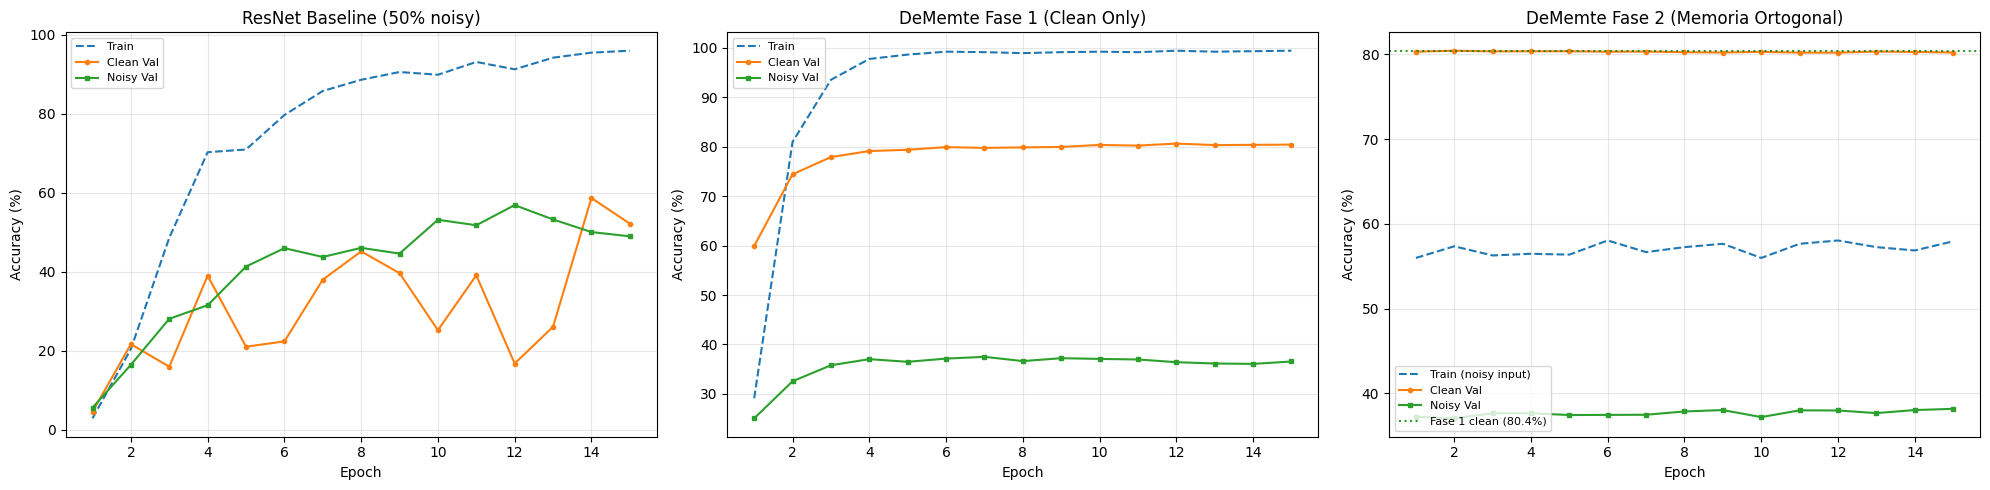

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ep = range(1, EPOCHS_P1 + 1)
ax.plot(ep, history_resnet['train_acc'], '--', label='Train')
ax.plot(ep, history_resnet['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep, history_resnet['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.set_title('ResNet Baseline (50% noisy)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ep, history_p1['train_acc'], '--', label='Train')
ax.plot(ep, history_p1['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep, history_p1['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.set_title('DeMemte Fase 1 (Clean Only)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ep2 = range(1, EPOCHS_P2 + 1)
ax.plot(ep2, history_p2['train_acc'], '--', label='Train (noisy input)')
ax.plot(ep2, history_p2['clean_acc'], '-o', markersize=3, label='Clean Val')
ax.plot(ep2, history_p2['noisy_acc'], '-s', markersize=3, label='Noisy Val')
ax.axhline(y=phase1_clean, color='green', linestyle=':', alpha=0.8, label=f'Fase 1 clean ({phase1_clean:.1f}%)')
ax.set_title('DeMemte Fase 2 (Memoria Ortogonal)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

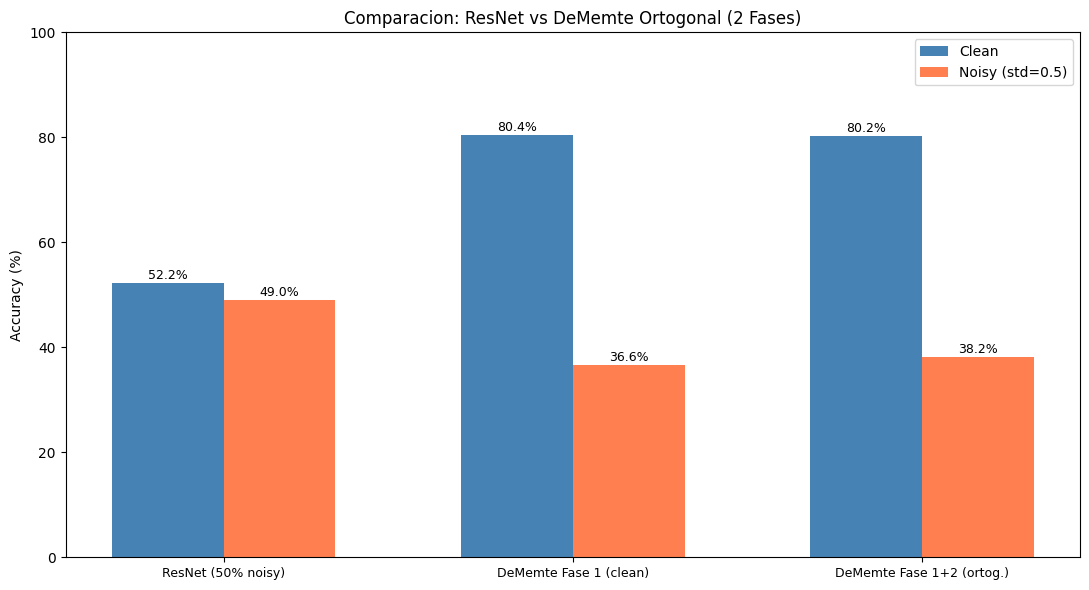

In [13]:
names = list(results.keys())
clean_vals = [results[n]['clean'] for n in names]
noisy_vals = [results[n]['noisy'] for n in names]

x = np.arange(len(names))
w = 0.32

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, clean_vals, w, label='Clean', color='steelblue')
b2 = ax.bar(x + w/2, noisy_vals, w, label='Noisy (std=0.5)', color='coral')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparacion: ResNet vs DeMemte Ortogonal (2 Fases)')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=9)
ax.legend()
ax.set_ylim(0, 100)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
os.makedirs('../out/dememte_orthogonal_flowers102', exist_ok=True)

save_path = '../out/dememte_orthogonal_flowers102/dememte_orthogonal_flowers102.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'metadata': {
        'variant': 'spatial_orthogonal_2phase',
        'dataset': 'Flowers102',
        'epochs_phase1': EPOCHS_P1,
        'epochs_phase2': EPOCHS_P2,
        'noise_std': NOISE_STD,
        'phase1_clean_acc': phase1_clean,
        'phase1_noisy_acc': phase1_noisy,
        'phase2_clean_acc': phase2_clean,
        'phase2_noisy_acc': phase2_noisy,
        'classifier_frozen_in_phase2': True,
    }
}, save_path)

resnet_path = '../out/dememte_orthogonal_flowers102/resnet_noisy_baseline.pth'
torch.save({
    'model_state_dict': resnet.state_dict(),
    'metadata': {
        'model': 'resnet18_noisy_baseline',
        'dataset': 'Flowers102',
        'epochs': EPOCHS_P1,
        'noise_std': NOISE_STD,
        'clean_acc': history_resnet['clean_acc'][-1],
        'noisy_acc': history_resnet['noisy_acc'][-1],
    }
}, resnet_path)

print(f'Saved: {save_path}')
print(f'Saved: {resnet_path}')

Saved: ../out/dememte_orthogonal_flowers102/dememte_orthogonal_flowers102.pth
Saved: ../out/dememte_orthogonal_flowers102/resnet_noisy_baseline.pth
